# 09. 상태 관리 (State Management)

> 체크포인터에 저장된 상태는 **읽기뿐 아니라 쓰기**도 가능해요. `update_state`, 메시지 ID 보존, history replay — 운영 시 자주 쓰는 기법을 한 번에 정리해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. **커스텀 상태(Custom State)** 를 TypedDict로 확장하여 `ask_human` 같은 플래그 필드를 추가할 수 있어요
2. **`update_state()`** 로 그래프 실행 도중 상태를 수동으로 주입하고, `as_node` 파라미터로 특정 노드를 시뮬레이션할 수 있어요
3. **메시지 ID 보존** 을 활용해 기존 메시지를 append 대신 replace하는 원리를 이해하고 도구 파라미터를 수정할 수 있어요
4. **`get_state_history()`** 로 체크포인트 히스토리를 순회하여 특정 시점으로 되돌아가 Replay할 수 있어요

## 사전 지식

- `08-Human-In-The-Loop.ipynb` — `interrupt`, `Command`, Time Travel
- `07-Memory-Checkpointer.ipynb` — `InMemorySaver`, `thread_id`, 체크포인트 개념
- `06-Tools-Integration.ipynb` — `ToolNode`, `tools_condition`, 조건부 엣지

## 개념 설명

지금까지는 `messages` 필드 하나만 있는 단순한 State에 의존해 왔어요. 하지만 복잡한 동작을 정의하려면 **상태에 추가 필드를 더하는 것**이 필요해요.

이번 노트북에서는 세 가지 핵심 기술을 배워요.

| 기술 | 설명 | 활용 시점 |
|------|------|----------|
| Custom State | TypedDict 확장, `ask_human` 같은 플래그 필드 추가 | 노드 분기 조건을 상태로 관리할 때 |
| `update_state()` | 그래프 외부에서 상태를 수동 업데이트 | 운영자 승인/교정, 외부 시스템 응답 주입, 도구 결과 수정 |
| `get_state_history()` | 전체 체크포인트 이력 순회 | 특정 시점 Replay, 롤백 |

> 🔑 **핵심 개념**: LangGraph의 상태(State)는 단순한 dict가 아니에요. `add_messages` 같은 **리듀서(Reducer)** 가 결합된 TypedDict이기 때문에, 동일한 메시지 ID로 업데이트하면 append가 아닌 **replace** 가 일어나요.

```mermaid
flowchart TD
    A["사용자 입력<br/>HumanMessage"] --> B["chatbot 노드<br/>LLM 추론"]
    B --> C{"select_next_node"}
    C -->|"ask_human=True"| D["human 노드<br/>interrupt_before"]
    C -->|"tool_calls 있음"| E["tools 노드<br/>ToolNode"]
    C -->|"종료"| F["END"]
    D --> G["update_state()<br/>외부 응답 주입"]
    G --> B
    E --> B

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef error fill:#f8d7da,stroke:#dc3545,color:#721c24

    class A input
    class B,E process
    class C,G storage
    class D error
    class F output
```

## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY, LANGCHAIN_API_KEY 등을 읽어와요
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택 사항)
# ---------------------------------------------------
# LangSmith에서 그래프 실행 흐름을 시각적으로 추적할 수 있어요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-Tutorial-09-State-Management"

---

## 1. Custom State — ask_human 플래그 추가

기존 State는 `messages` 필드 하나였어요. 이번에는 `ask_human: bool` 필드를 추가해서, LLM이 외부 검토자에게 확인을 요청하는 특수 도구를 호출했을 때 플래그를 활성화하는 구조를 만들어볼게요.

> 🎯 **강의 포인트**: `ask_human` 플래그는 그래프의 **조건부 엣지** 함수가 참조해요. 상태 필드를 라우팅 조건으로 활용하는 이 패턴은 단순 HITL과 선택적 HITL을 구분하는 핵심 기법이에요.

> 💡 **실무 팁**: `ask_human` 같은 플래그 필드는 **교통 신호등**과 같아요. 초록불(`ask_human=False`)이면 자동으로 진행하고, 빨간불(`ask_human=True`)이면 멈추고 사람의 지시를 기다려요. 이 패턴은 에이전트의 자율성을 상황에 따라 조절하는 핵심 기법이에요.

> 🔑 **핵심 개념**: TypedDict에 기본값이 없는 `bool` 필드를 추가할 때, 초기 State 생성 시 해당 필드를 명시적으로 설정해야 에러가 나지 않아요. 노드에서 반환하는 dict에 필드가 없으면 이전 값이 유지돼요.

In [3]:
# ---------------------------------------------------
# Custom State 정의
# ---------------------------------------------------
# messages: add_messages 리듀서로 메시지를 누적해요
# ask_human: LLM이 HumanRequest 도구를 호출했는지 추적하는 플래그예요
from typing import Annotated

from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]  # 메시지 목록 (누적)
    ask_human: bool  # 외부 검토가 필요한지 여부

In [4]:
# ---------------------------------------------------
# HumanRequest 스키마 정의
# ---------------------------------------------------
# LLM이 이 도구를 호출하면 ask_human 플래그가 True로 설정돼요
# 실제 실행되는 도구가 아니라, LLM의 의도를 상태에 반영하는 '신호 도구'예요
from pydantic import BaseModel


class HumanRequest(BaseModel):
    """Forward the conversation to a human reviewer.
    Use when the workflow needs an external decision before continuing.
    Pass the user's 'request' so the reviewer can provide the required input.
    """

    request: str  # 외부 검토자에게 전달할 요청 내용

In [5]:
# ---------------------------------------------------
# 도구 정의 및 LLM 초기화
# ---------------------------------------------------
# TavilySearch: 웹 검색 도구 (langchain-tavily 패키지 사용)
# HumanRequest: 신호 도구 (실행되지 않고 플래그만 전환)
from langchain_tavily import TavilySearch as TavilySearchResults  # langchain-tavily 패키지 사용 (최신 V1 방식)
from langchain.chat_models import init_chat_model

# 웹 검색 도구 (최대 3개 결과)
search_tool = TavilySearchResults(max_results=3)  # langchain-tavily의 TavilySearch

# 도구 목록: 웹 검색 + 외부 검토 요청
tools = [search_tool, HumanRequest]

# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성)
# 다른 모델 옵션: "anthropic:claude-sonnet-4-5", "google_genai:gemini-2.0-flash"
llm = init_chat_model("openai:gpt-4o-mini")

# 도구를 LLM에 바인딩해요
llm_with_tools = llm.bind_tools(tools)

In [6]:
# ---------------------------------------------------
# chatbot 노드 정의
# ---------------------------------------------------
# LLM이 HumanRequest를 호출하면 ask_human = True로 설정해요
# 이 플래그를 조건부 엣지에서 확인해서 human 노드로 분기해요


def chatbot(state: State):
    """LLM을 호출하고, HumanRequest 도구 호출 여부에 따라 플래그를 설정해요."""
    response = llm_with_tools.invoke(state["messages"])

    # ask_human 플래그 초기화
    ask_human = False

    # LLM이 HumanRequest를 호출했는지 확인해요
    if response.tool_calls and response.tool_calls[0]["name"] == HumanRequest.__name__:
        ask_human = True

    return {"messages": [response], "ask_human": ask_human}

---

## 2. Human 노드와 조건부 분기

Human 노드는 항상 `interrupt_before` 로 중단되는 **자리 표시자(placeholder)** 역할을 해요. 실행 시 사람이 응답을 입력하지 않으면, 자동으로 "응답 없음" ToolMessage를 생성해서 그래프가 계속 진행될 수 있게 해요.

> ⚠️ **자주 하는 실수**: `human_node`에서 생성하는 `ToolMessage`의 `tool_call_id`는 반드시 직전 AI 메시지의 `tool_calls[0]["id"]`와 일치해야 해요. ID가 틀리면 LLM이 도구 응답을 연결하지 못해서 에러가 발생해요.

In [7]:
# ---------------------------------------------------
# Human 노드와 ToolMessage 생성 헬퍼
# ---------------------------------------------------
# create_response: AIMessage의 tool_call_id에 맞는 ToolMessage를 생성해요
# human_node: interrupt_before로 중단 후, 사람 응답이 없으면 기본값을 넣어요
from langchain_core.messages import AIMessage, ToolMessage


def create_response(response: str, ai_message: AIMessage) -> ToolMessage:
    """AI 메시지의 tool_call_id에 맞는 ToolMessage를 생성해요."""
    print(ai_message.tool_calls)
    return ToolMessage(
        content=response,
        tool_call_id=ai_message.tool_calls[0]["id"],  # ID 매칭 필수!
    )


def human_node(state: State) -> dict:
    """사람의 응답을 기다리는 노드예요.
    interrupt_before로 중단되며, 응답이 없으면 기본 메시지를 삽입해요.
    """
    new_messages = []

    # 마지막 메시지가 ToolMessage가 아닌 경우 = 사람이 응답하지 않은 경우
    if not isinstance(state["messages"][-1], ToolMessage):
        new_messages.append(
            create_response("No response from human.", state["messages"][-1])
        )

    return {
        "messages": new_messages,
        "ask_human": False,  # 플래그를 다시 해제해요
    }

In [8]:
# ---------------------------------------------------
# 조건부 라우팅 함수
# ---------------------------------------------------
# select_next_node:
#   1. ask_human=True  → human 노드로
#   2. tool_calls 있음  → tools 노드로 (tools_condition이 판단)
#   3. 그 외            → END
from langgraph.graph import END
from langgraph.prebuilt import tools_condition


def select_next_node(state: State) -> str:
    """다음 노드를 선택해요."""
    # 외부 검토 요청 플래그가 설정되어 있으면 human 노드로 분기
    if state["ask_human"]:
        return "human"
    # 그 외엔 기존 tools_condition 로직 (도구 호출 여부 확인)
    return tools_condition(state)

---

## 3. 그래프 조립 및 시각화

In [9]:
# ---------------------------------------------------
# 그래프 빌더 조립
# ---------------------------------------------------
# interrupt_before=["human"]: human 노드 실행 직전에 중단해서
#   외부에서 update_state()로 검토자 응답을 주입할 수 있어요
from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

# 그래프 빌더 초기화
graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=[search_tool]))  # HumanRequest는 제외!
graph_builder.add_node("human", human_node)

# 조건부 엣지: chatbot → select_next_node → human/tools/END
graph_builder.add_conditional_edges(
    "chatbot",
    select_next_node,
    {"human": "human", "tools": "tools", END: END},
)

# 단방향 엣지
graph_builder.add_edge("tools", "chatbot")   # 도구 실행 후 chatbot으로 돌아와요
graph_builder.add_edge("human", "chatbot")   # 외부 응답 주입 후 chatbot으로 돌아와요
graph_builder.add_edge(START, "chatbot")     # 시작점

# 체크포인터 + interrupt_before 설정
memory = MemorySaver()
graph = graph_builder.compile(
    checkpointer=memory,
    interrupt_before=["human"],  # human 노드 직전에 중단!
)

# 그래프 컴파일 완료!

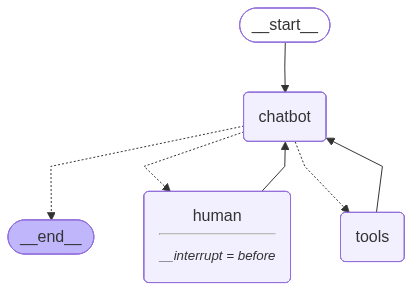

In [10]:
# 그래프 흐름: START → chatbot → human/tools/END
# chatbot 노드: LLM이 메시지를 처리하고 도구 호출 또는 사람 전달을 결정해요
# tools 노드: 도구를 실행하고 chatbot으로 돌아와요
# human 노드: 외부 응답 주입 후 chatbot으로 돌아와요
# 조건부 엣지: 도구 호출, 사람 요청, 일반 응답으로 3-way 분기해요
# ---------------------------------------------------
# 그래프 시각화
# ---------------------------------------------------
# chatbot → human/tools/END 세 가지 경로가 보여요
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

---

## 4. 외부 응답을 상태에 주입하기 — update_state()와 as_node

`update_state()`는 그래프 외부에서 상태를 수동으로 업데이트하는 메서드예요. 여기서 중요한 것은 그래프가 멈춘 뒤 **외부 시스템이나 사람이 만든 결과를 마치 특정 노드가 방금 반환한 값처럼 체크포인트에 기록하고 이어 실행하는 방법**이에요.

실무에서는 상담원이 관리자 콘솔에서 입력한 답변, Slack 승인 메시지, 운영자가 수정한 SQL/검색 쿼리, 장애 복구 중 수동으로 보정한 상태처럼 **그래프 밖에서 만들어진 결정**을 다시 그래프 안으로 넣어야 할 때가 있어요. 이때 `update_state()`를 사용하면 기존 체크포인트를 직접 덮어쓰는 것이 아니라, 리듀서를 적용한 **새 체크포인트**를 만들고 그 지점부터 실행을 이어갈 수 있어요.

이번 예제는 외부 검토자가 입력한 응답을 `ToolMessage`로 주입하는 흐름을 사용해 이 패턴을 보여줘요. 일반적인 승인/거부 HITL만 필요하다면 `interrupt()` + `Command(resume=...)` 또는 `HumanInTheLoopMiddleware`가 더 자연스럽지만, 응답을 `ToolMessage`로 직접 구성하거나 도구 호출 인자 자체를 교정해야 할 때는 `update_state()`가 더 세밀한 제어를 제공해요.

> 🎯 **강의 포인트**: `update_state(config, values, as_node=)` 의 `as_node` 파라미터가 핵심이에요. 이 값을 `"human"`으로 지정하면, 그래프가 "human 노드가 방금 실행됐다"고 인식해서 다음 노드(chatbot)로 올바르게 이동해요.

> 💡 **실무 팁**: `as_node`를 생략하면 마지막으로 실행된 노드를 기준으로 자동 판단해요. 하지만 ambiguous한 경우 오류가 발생할 수 있으니, 명확하게 지정하는 것이 안전해요.

In [11]:
# ---------------------------------------------------
# 1단계: 외부 검토가 필요한 메시지로 그래프 실행
# ---------------------------------------------------
# LLM이 HumanRequest 도구를 호출하면 interrupt_before=["human"]에서 중단돼요
user_input = "고객 환불 요청을 처리하기 전에 운영자 확인이 필요합니다. 검토를 요청해 주세요."

# 스레드 ID 설정 (대화 세션 구분)
config = {"configurable": {"thread_id": "thread-external-review"}}

# 그래프 스트리밍 실행
events = graph.stream(
    {"messages": [("user", user_input)], "ask_human": False},
    config,
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

고객 환불 요청을 처리하기 전에 운영자 확인이 필요합니다. 검토를 요청해 주세요.
================================== Ai Message ==================================
Tool Calls:
  HumanRequest (call_4SzrvWIWKztrCzMLbJM57kHM)
 Call ID: call_4SzrvWIWKztrCzMLbJM57kHM
  Args:
    request: 고객 환불 요청의 검토를 부탁드립니다. 운영자의 확인이 필요합니다.


In [12]:
# ---------------------------------------------------
# 2단계: 그래프 상태 확인 — 어디서 중단됐는지
# ---------------------------------------------------
snapshot = graph.get_state(config)

print("다음 실행 노드:", snapshot.next)  # ('human',) 이어야 해요
print("ask_human 플래그:", snapshot.values["ask_human"])  # True 이어야 해요

다음 실행 노드: ('human',)
ask_human 플래그: True


In [13]:
# ---------------------------------------------------
# 3단계: 외부 응답 주입 — update_state()
# ---------------------------------------------------
# tool_call_id를 정확히 매칭해야 해요!
# AI 메시지의 tool_calls[0]["id"]를 사용해요

# 직전 AI 메시지 추출
ai_message = snapshot.values["messages"][-1]

# 외부에서 들어온 응답 내용
# 예: 상담원/관리자 콘솔/Slack 승인 플로우에서 받은 메시지
external_response = (
    "운영자 확인 결과, 최근 7일 이내 결제 건이면 전액 환불이 가능합니다. "
    "고객에게 환불 처리 가능 여부를 안내하고, 주문 번호와 결제 수단 확인을 요청하세요."
)

# ToolMessage 생성 (tool_call_id 매칭 필수!)
tool_message = create_response(external_response, ai_message)

# 상태 업데이트: as_node="human"으로 human 노드가 이 값을 반환한 것처럼 처리
graph.update_state(
    config,
    {"messages": [tool_message], "ask_human": False},
    as_node="human",  # 다음 실행 위치를 human 노드의 후속 노드로 정렬해요
)

# 상태 업데이트 완료!
print("업데이트 후 다음 노드:", graph.get_state(config).next)

[{'name': 'HumanRequest', 'args': {'request': '고객 환불 요청의 검토를 부탁드립니다. 운영자의 확인이 필요합니다.'}, 'id': 'call_4SzrvWIWKztrCzMLbJM57kHM', 'type': 'tool_call'}]
업데이트 후 다음 노드: ('chatbot',)


In [14]:
# ---------------------------------------------------
# 4단계: 외부 응답을 받은 후 그래프 재개
# ---------------------------------------------------
# None을 입력하면 현재 상태에서 이어서 실행해요
events = graph.stream(None, config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================= Tool Message =================================

운영자 확인 결과, 최근 7일 이내 결제 건이면 전액 환불이 가능합니다. 고객에게 환불 처리 가능 여부를 안내하고, 주문 번호와 결제 수단 확인을 요청하세요.
================================== Ai Message ==================================

운영자 확인 결과, 최근 7일 이내 결제 건은 전액 환불이 가능합니다. 고객에게 환불 처리 가능 여부를 안내하고, 주문 번호와 결제 수단 확인을 요청해 주세요.


---

## 5. 도구 파라미터 수정 — 메시지 ID 보존

그래프가 도구 노드에서 중단됐을 때, LLM이 생성한 **검색 쿼리나 도구 인자가 마음에 들지 않으면 수정**할 수 있어요.

`add_messages` 리듀서의 특성을 활용해요: **같은 ID로 메시지를 update_state하면 append가 아니라 replace**가 일어나요.

```mermaid
flowchart LR
    A["interrupt_before tools"] --> B["기존 AIMessage<br/>query: 원본 쿼리"]
    B --> C["동일 ID로<br/>새 AIMessage 생성"]
    C --> D["update_state() 호출"]
    D --> E["리듀서: ID 일치<br/>→ replace"]
    E --> F["그래프 재개<br/>수정된 쿼리로 검색"]

    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class A,B process
    class C,D,E storage
    class F output
```

> 🔑 **핵심 개념**: `add_messages` 리듀서는 메시지 ID를 기준으로 동작해요.
> - **다른 ID**: 기존 목록에 **추가(append)**
> - **같은 ID**: 기존 메시지를 **교체(replace)**
>
> 이 특성을 활용해서 도구 파라미터를 수정할 수 있어요.

> ⚠️ **자주 하는 실수**: 새 AIMessage를 만들 때 `id=existing_message.id`를 빠뜨리면, 메시지가 교체되지 않고 **추가**되어 메시지가 중복될 수 있어요. 이는 LangGraph에서 가장 자주 발생하는 버그 중 하나예요.

### add_messages 리듀서의 ID 기반 동작 요약

| 새 메시지의 ID | 기존 메시지에 같은 ID | 결과 |
|---------------|---------------------|------|
| 없음 (자동 생성) | - | **추가(append)**: 새 메시지가 리스트 끝에 추가 |
| `id="msg-1"` | 없음 | **추가(append)**: 새 메시지가 리스트 끝에 추가 |
| `id="msg-1"` | 있음 | **교체(replace)**: 기존 메시지를 새 메시지로 대체 |

In [15]:
# ---------------------------------------------------
# 새 그래프 세션 시작 — 도구 파라미터 수정 실습
# ---------------------------------------------------
# 별도의 그래프를 사용해요 (tools 노드 포함, interrupt_before=["tools"])
# 이번에는 검색 도구만 있는 더 단순한 그래프를 만들어요
from typing import Annotated
from typing_extensions import TypedDict
from langchain_tavily import TavilySearch as TavilySearchResults  # langchain-tavily 패키지 사용 (최신 V1 방식)
from langchain.chat_models import init_chat_model
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


# 검색 전용 간단한 State
class SearchState(TypedDict):
    messages: Annotated[list, add_messages]


# 검색 도구 초기화
search_tool_only = TavilySearchResults(max_results=2)
search_tools = [search_tool_only]

# LLM 초기화 (병렬 도구 호출 비활성화 — 단일 쿼리로 단순하게)
search_llm = init_chat_model("openai:gpt-4o-mini")
search_llm_with_tools = search_llm.bind_tools(
    search_tools,
    parallel_tool_calls=False,  # 도구를 하나씩 순서대로 호출해요
)


def search_chatbot(state: SearchState):
    """검색 챗봇 노드예요."""
    return {"messages": [search_llm_with_tools.invoke(state["messages"])]}


# 그래프 조립
search_builder = StateGraph(SearchState)
search_builder.add_node("chatbot", search_chatbot)
search_builder.add_node("tools", ToolNode(tools=search_tools))
search_builder.add_conditional_edges("chatbot", tools_condition)
search_builder.add_edge("tools", "chatbot")
search_builder.add_edge(START, "chatbot")

search_memory = MemorySaver()
search_graph = search_builder.compile(checkpointer=search_memory)

# 검색 그래프 컴파일 완료!

In [16]:
# ---------------------------------------------------
# interrupt_before=["tools"]로 도구 실행 전 중단
# ---------------------------------------------------
# 스트림 실행 시 interrupt_before를 직접 지정할 수도 있어요
import uuid

thread_id = str(uuid.uuid4())[:8]  # 짧은 랜덤 ID 생성
search_config = RunnableConfig(configurable={"thread_id": thread_id})

question = "LangGraph 에 대해서 공식 사이트에서 검색해서 알려주세요!"

events = search_graph.stream(
    {"messages": [("user", question)]},
    search_config,
    interrupt_before=["tools"],  # tools 노드 직전에 중단!
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

LangGraph 에 대해서 공식 사이트에서 검색해서 알려주세요!
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_d06cENngUSm7dZqvM3vYzTl7)
 Call ID: call_d06cENngUSm7dZqvM3vYzTl7
  Args:
    query: LangGraph official site
    include_domains: ['langgraph.com']


In [17]:
# ---------------------------------------------------
# 현재 상태에서 도구 호출 파라미터 확인
# ---------------------------------------------------
# LLM이 생성한 검색 쿼리를 확인해요
search_snapshot = search_graph.get_state(search_config)
existing_message = search_snapshot.values["messages"][-1]

print("현재 메시지 ID:", existing_message.id)
# 도구 호출 정보:
print(existing_message.tool_calls[0])

현재 메시지 ID: lc_run--019e3885-78aa-7cf1-a41e-b60ef7226fc3-0
{'name': 'tavily_search', 'args': {'query': 'LangGraph official site', 'include_domains': ['langgraph.com']}, 'id': 'call_d06cENngUSm7dZqvM3vYzTl7', 'type': 'tool_call'}


In [18]:
# ---------------------------------------------------
# 검색 쿼리 수정 — 같은 ID로 메시지 교체
# ---------------------------------------------------
# 핵심: id=existing_message.id 를 반드시 유지해야 해요!
# 같은 ID로 update_state를 호출하면 리듀서가 기존 메시지를 교체해요
from langchain_core.messages import AIMessage

# 기존 tool_calls를 복사해서 쿼리만 수정해요
new_tool_call = existing_message.tool_calls[0].copy()
new_tool_call["args"] = {"query": "LangGraph site:github.com/langchain-ai/langchain"}

# 새 AIMessage 생성 — ID는 기존 메시지와 동일하게!
new_message = AIMessage(
    content=existing_message.content,
    tool_calls=[new_tool_call],
    id=existing_message.id,  # 같은 ID → replace (추가가 아님!)
)

print("수정된 쿼리:", new_tool_call["args"])
print("메시지 ID 확인:", new_message.id == existing_message.id)

수정된 쿼리: {'query': 'LangGraph site:github.com/langchain-ai/langchain'}
메시지 ID 확인: True


In [19]:
# ---------------------------------------------------
# update_state()로 수정된 메시지 반영
# ---------------------------------------------------
# as_node="tools"로 지정해서 tools 노드 입력이 갱신된 것처럼 처리해요
search_graph.update_state(
    search_config,
    {"messages": [new_message]},
    as_node="chatbot",  # chatbot 노드가 방금 실행된 것처럼 처리
)

# 업데이트 후 도구 호출 확인
updated_tool_calls = search_graph.get_state(search_config).values["messages"][-1].tool_calls
print("업데이트 후 쿼리:", updated_tool_calls[0]["args"])

업데이트 후 쿼리: {'query': 'LangGraph site:github.com/langchain-ai/langchain'}


In [20]:
# ---------------------------------------------------
# 수정된 쿼리로 그래프 재개
# ---------------------------------------------------
# None 입력으로 현재 상태에서 이어서 실행해요
events = search_graph.stream(None, search_config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_d06cENngUSm7dZqvM3vYzTl7)
 Call ID: call_d06cENngUSm7dZqvM3vYzTl7
  Args:
    query: LangGraph site:github.com/langchain-ai/langchain
================================= Tool Message =================================
Name: tavily_search

{"query": "LangGraph", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://github.com/langchain-ai/langchain", "title": "langchain-ai/langchain: The agent engineering platform. - GitHub", "content": "[Skip to content](https://github.com/langchain-ai/langchain#start-of-content). *   [AI](https://github.com/resources/articles?topic=ai). [Reload](https://github.com/langchain-ai/langchain) to refresh your session.You signed out in another tab or window. [Reload](https://github.com/langchain-ai/langchain) to refresh your session.You switched accounts on another tab or window. [Reload](https://github.com/langcha

---

## 6. 상태 히스토리와 Replay — get_state_history()

지금까지 `update_state()`로 상태를 수동으로 수정하는 방법을 배웠어요. 이제 한 걸음 더 나아가, 특정 과거 시점으로 되돌아가서 **다른 선택을 해보는** 방법을 알아볼게요. 마치 게임의 세이브 포인트를 불러오는 것과 같아요.

`get_state_history(config)`는 특정 스레드의 모든 체크포인트를 **역순**(최신 → 과거)으로 순회해요. 원하는 시점을 골라 해당 상태에서 **Replay**할 수 있어요.

> 🎯 **강의 포인트**: Replay는 단순히 이전 상태를 조회하는 것이 아니에요. `update_state(past_config, ...)` 후 `graph.stream(None, new_config)` 를 호출하면, **해당 시점부터 새로운 브랜치를 생성**해서 다른 경로를 탐색할 수 있어요. Time Travel의 실용적 응용이에요.

> 💡 **실무 팁**: `state.config`는 해당 체크포인트를 가리키는 RunnableConfig예요. `graph.stream(None, state.config)`로 호출하면 그 시점부터 이어서 실행할 수 있어요.

In [21]:
# ---------------------------------------------------
# 전체 상태 히스토리 조회
# ---------------------------------------------------
# get_state_history()는 최신 → 과거 순으로 체크포인트를 반환해요
# === 상태 히스토리 (최신 순) ===
print()

to_replay_state = None

for state in search_graph.get_state_history(search_config):
    msg_count = len(state.values["messages"])
    next_nodes = state.next

    if msg_count > 0:
        last_msg_id = state.values["messages"][-1].id
        print(f"메시지 수: {msg_count:2d}  다음 노드: {str(next_nodes):<20}  마지막 ID: {last_msg_id[:30]}...")

        # 메시지가 2개인 시점을 Replay 대상으로 선택 (첫 도구 호출 직후)
        if msg_count == 2:
            to_replay_state = state

print()
print("Replay 대상 시점:", to_replay_state.next if to_replay_state else "없음")


메시지 수:  4  다음 노드: ()                    마지막 ID: lc_run--019e3885-822a-7e53-848...
메시지 수:  3  다음 노드: ('chatbot',)          마지막 ID: ad8a7e18-d628-4b2c-a7ab-76218d...
메시지 수:  2  다음 노드: ('tools',)            마지막 ID: lc_run--019e3885-78aa-7cf1-a41...
메시지 수:  2  다음 노드: ('tools',)            마지막 ID: lc_run--019e3885-78aa-7cf1-a41...
메시지 수:  1  다음 노드: ('chatbot',)          마지막 ID: 8f3dc19c-80b7-43b3-a40f-dff758...

Replay 대상 시점: ('tools',)


In [22]:
# ---------------------------------------------------
# Replay 대상 메시지 확인
# ---------------------------------------------------
# 메시지가 2개인 시점 = 사용자 질문 + 첫 번째 LLM 응답(tool_calls)
if to_replay_state:
    replay_message = to_replay_state.values["messages"][-1]
    print("Replay 대상 메시지 타입:", type(replay_message).__name__)
    print("도구 호출:", replay_message.tool_calls[0] if replay_message.tool_calls else "없음")

Replay 대상 메시지 타입: AIMessage
도구 호출: {'name': 'tavily_search', 'args': {'query': 'LangGraph official site', 'include_domains': ['langgraph.com']}, 'id': 'call_d06cENngUSm7dZqvM3vYzTl7', 'type': 'tool_call'}


In [23]:
# ---------------------------------------------------
# 과거 시점의 쿼리를 다른 값으로 교체하여 Replay
# ---------------------------------------------------
# to_replay_state.config: 해당 체크포인트를 가리키는 config
if to_replay_state:
    existing_msg = to_replay_state.values["messages"][-1]

    # 새 쿼리로 tool_call 수정
    replay_tool_call = existing_msg.tool_calls[0].copy()
    replay_tool_call["args"] = {"query": "LangGraph tutorials beginner guide 2026"}

    # ID 유지하여 교체
    replay_new_message = AIMessage(
        content=existing_msg.content,
        tool_calls=[replay_tool_call],
        id=existing_msg.id,  # 반드시 기존 ID 유지!
    )

    # 과거 시점의 상태를 업데이트
    updated_config = search_graph.update_state(
        to_replay_state.config,  # 과거 체크포인트 config
        {"messages": [replay_new_message]},
    )

    # Replay 설정 완료!
    print("새 쿼리:", replay_tool_call["args"])

새 쿼리: {'query': 'LangGraph tutorials beginner guide 2026'}


In [24]:
# ---------------------------------------------------
# 수정된 과거 시점에서 새 브랜치로 Replay 실행
# ---------------------------------------------------
# updated_config: 방금 update_state()가 반환한 새 체크포인트
if to_replay_state:
    for event in search_graph.stream(None, updated_config, stream_mode="values"):
        if "messages" in event:
            event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_d06cENngUSm7dZqvM3vYzTl7)
 Call ID: call_d06cENngUSm7dZqvM3vYzTl7
  Args:
    query: LangGraph tutorials beginner guide 2026
================================= Tool Message =================================
Name: tavily_search

{"query": "LangGraph tutorials beginner guide 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/watch?v=Hz21KVo0t4E", "title": "Complete LangGraph Tutorial Beginner To Advance 2026 | RAG-Full-Course", "content": "Complete LangGraph Tutorial Beginner To Advance 2026 | RAG-Full-Course\nWizard Engineer\n4200 subscribers\n109 likes\n3628 views\n18 Mar 2026\nIn this complete LangGraph tutorial, you will learn how to build advanced AI agents, multi-agent systems, and Retrieval-Augmented Generation (RAG) applications from scratch.\n\nLangGraph is one of the most powerful frameworks for building st

---

## 7. 실습 — 커스텀 필드로 대화 감정 추적하기

아래 TODO를 완성해서 `mood` 필드를 State에 추가하고, chatbot 노드가 응답할 때마다 현재 대화 분위기를 추적해보세요.

> 💡 **실무 팁**: 이 패턴은 실제 프로덕션에서 에이전트의 **신뢰도(confidence)**, **비용 추적**, **사용자 의도 분류** 등을 상태로 관리할 때 사용해요.

In [25]:
# ============================================================
# 구현 예시: mood 필드가 있는 커스텀 State
# ============================================================
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain.chat_models import init_chat_model
import uuid


class MoodState(TypedDict):
    messages: Annotated[list, add_messages]
    mood: str


mood_llm = init_chat_model("openai:gpt-4o-mini")

POSITIVE_KEYWORDS = ["감사", "좋", "기대", "도움", "행복", "재미"]
NEGATIVE_KEYWORDS = ["힘들", "어렵", "모르", "불안", "문제", "실패"]


def classify_mood(text: str) -> str:
    """간단한 키워드 규칙으로 대화 분위기를 분류해요."""
    if any(keyword in text for keyword in POSITIVE_KEYWORDS):
        return "positive"
    if any(keyword in text for keyword in NEGATIVE_KEYWORDS):
        return "negative"
    return "neutral"


def mood_chatbot(state: MoodState):
    response = mood_llm.invoke(state["messages"])
    latest_user_text = state["messages"][-1].content
    combined_text = f"{latest_user_text}\n{response.content}"
    mood = classify_mood(combined_text)
    return {"messages": [response], "mood": mood}


mood_builder = StateGraph(MoodState)
mood_builder.add_node("chatbot", mood_chatbot)
mood_builder.add_edge(START, "chatbot")
mood_builder.add_edge("chatbot", END)

mood_memory = MemorySaver()
mood_graph = mood_builder.compile(checkpointer=mood_memory)

mood_config = {"configurable": {"thread_id": str(uuid.uuid4())}}

test_messages = [
    "안녕하세요! 오늘 LangGraph를 배우게 되어서 정말 기대돼요!",
    "감사합니다, 많은 도움이 됐어요!",
    "아직 체크포인터 개념은 조금 어려워요.",
]

for msg in test_messages:
    result = mood_graph.invoke(
        {"messages": [("user", msg)], "mood": "neutral"},
        mood_config,
    )
    print(f"메시지: {msg[:30]}...")
    print(f"현재 mood: {result['mood']}")
    print()


메시지: 안녕하세요! 오늘 LangGraph를 배우게 되어서 정...
현재 mood: positive

메시지: 감사합니다, 많은 도움이 됐어요!...
현재 mood: positive

메시지: 아직 체크포인터 개념은 조금 어려워요....
현재 mood: neutral



---

## 7. 가상의 실무 시나리오 — while 루프로 이어지는 승인/거부 대화

이 마지막 예제의 목표는 **HITL(Human-in-the-loop)** 과 **State Management** 를 한 번에 체감하는 것입니다.

사용자가 일반 질문을 하면 LLM이 바로 답합니다. 하지만 환불, 결제, 삭제, 메일 전송처럼 실제 행동으로 이어질 수 있는 요청이면 LLM이 먼저 멈춰서 사용자에게 **`승인` 또는 `거부`** 를 요청합니다.

```mermaid
flowchart TD
    A["사용자 입력"] --> B["llm_review_request<br/>승인 필요 여부 판단"]
    B --> C{"승인 필요?"}
    C -->|"아니오"| D["AI 즉시 답변"]
    C -->|"예"| E["human_approval 앞에서 중단"]
    E --> F["get_state()로<br/>중단 지점 확인"]
    F --> G["사용자 승인/거부 입력"]
    G --> H["update_state(..., as_node='human_approval')"]
    H --> I["stream(None, config)로 재개"]
    I --> J["answer_after_approval<br/>최종 답변"]
```

> 🎯 **학습 포인트**  
> 이 예제는 실무 시스템을 완성하는 코드라기보다, 체크포인터에 저장된 상태를 사람이 확인하고 `update_state()`로 보정한 뒤 같은 `thread_id`에서 이어 실행하는 흐름을 이해하기 위한 수업용 예제입니다.
>
> 참고: 공식 문서에서는 실제 프로덕션 HITL에는 노드 내부의 `interrupt()` + `Command(resume=...)` 패턴을 더 권장합니다. 여기서는 이번 노트북의 주제인 `get_state()`, `update_state()`, `as_node`, 체크포인트 재개를 명확히 보여주기 위해 `interrupt_before`를 사용합니다.


### 실행 방법

아래 셀들을 위에서 아래로 차례대로 실행하세요.

1. State와 구조화 출력 모델을 정의합니다.
2. LLM에게 “승인이 필요한 요청인지” 판단하게 하는 프롬프트를 설정합니다.
3. 그래프 노드 함수를 정의합니다.
4. 그래프를 컴파일하고 같은 `thread_id`로 대화를 이어갑니다.
5. 마지막 while 루프 셀에서 직접 입력해 봅니다.

예시 입력:

```text
LangGraph의 State가 뭐야?
배송이 늦었으니 환불 처리해줘.
내 계정을 삭제해줘.
```

승인 요청이 나오면 정확히 다음 둘 중 하나로 답하세요.

```text
승인
거부
```

종료하려면 `q`, `quit`, `exit` 중 하나를 입력하면 됩니다.

> ⚠️ 이 예제는 실제 환불, 삭제, 메일 발송 같은 외부 작업을 실행하지 않습니다. 승인/거부 이후에 어떤 메시지를 만들지 보여주는 수업용 시뮬레이션입니다.


In [26]:
# ------------------------------------------------------------
# 1단계: 필요한 객체 import + State 정의
# ------------------------------------------------------------
# State는 그래프 전체가 공유하는 데이터 구조예요.
# 각 노드는 이 State를 읽고, 일부 필드만 업데이트해서 반환합니다.

from operator import add
from typing import Annotated, Literal
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
import uuid


class ApprovalChatState(TypedDict):
    # messages는 대화 기록입니다.
    # add_messages 리듀서를 사용하면 새 메시지는 append되고,
    # 같은 id의 메시지는 replace됩니다.
    messages: Annotated[list[BaseMessage], add_messages]

    # 승인이 필요한 경우, 어떤 사용자 요청이 대기 중인지 저장합니다.
    pending_request: str

    # LLM이 판단한 승인 필요 이유입니다.
    approval_reason: str

    # 사용자에게 보여줄 "승인/거부" 질문입니다.
    approval_question: str

    # 사용자가 실제로 입력한 판단입니다. 값은 "승인" 또는 "거부"가 됩니다.
    approval_decision: str

    # 각 단계에서 무슨 일이 있었는지 누적하는 간단한 로그입니다.
    audit_log: Annotated[list[str], add]


class ApprovalPlan(BaseModel):
    """LLM이 이번 사용자 요청을 어떻게 처리할지 구조화해서 반환해요."""

    needs_approval: bool = Field(description="사용자의 명시적 승인/거부가 필요한 요청이면 true")
    reason: str = Field(description="승인이 필요한 이유. 필요 없으면 빈 문자열")
    approval_question: str = Field(description="사용자에게 보여줄 승인/거부 질문. 필요 없으면 빈 문자열")
    safe_reply: str = Field(description="승인이 필요 없는 경우 바로 사용자에게 보낼 답변")


### 2단계 — LLM에게 승인 필요 여부를 판단하게 하기

이 셀에서는 LLM에게 다음 역할을 맡깁니다.

- 일반 질문이면 바로 답변하기
- 돈, 삭제, 외부 발송, 예약 확정처럼 실제 행동을 일으키는 요청이면 승인 게이트로 보내기
- 승인 게이트로 보낼 때는 반드시 사용자가 **`승인` 또는 `거부`** 로 답하게 만들기

여기서 `with_structured_output(ApprovalPlan)`을 사용하므로, LLM 응답을 문자열이 아니라 `ApprovalPlan` 객체처럼 다룰 수 있습니다.


In [27]:
# ------------------------------------------------------------
# 2단계: LLM + 구조화 출력 설정
# ------------------------------------------------------------
# 이 셀은 OPENAI_API_KEY가 준비되어 있어야 실행됩니다.

approval_llm = init_chat_model("openai:gpt-4o-mini")
approval_planner = approval_llm.with_structured_output(ApprovalPlan)

APPROVAL_SYSTEM_PROMPT = """
너는 LangGraph 수업용 한국어 챗봇이다.
사용자의 최신 요청을 보고 승인이 필요한지 판단한다.

승인이 필요한 요청의 예:
- 환불, 결제, 주문 취소처럼 돈이나 거래에 영향을 주는 요청
- 계정 삭제, 데이터 삭제, 권한 변경처럼 되돌리기 어려운 요청
- 이메일/문자 발송, 예약 확정처럼 외부 시스템에 행동을 일으키는 요청

승인이 필요하면:
- needs_approval=true
- approval_question에는 반드시 사용자가 정확히 '승인' 또는 '거부'로 답하도록 요청한다
- safe_reply는 빈 문자열로 둔다

승인이 필요하지 않으면:
- needs_approval=false
- safe_reply에 바로 답변한다
- reason과 approval_question은 빈 문자열로 둔다
""".strip()


### 3단계 — 첫 번째 노드: LLM 검토 노드

`llm_review_request` 노드는 그래프의 첫 번째 실제 작업 노드입니다.

이 노드가 하는 일은 두 가지입니다.

1. 가장 최근 사용자 메시지를 찾습니다.
2. LLM에게 “이 요청은 승인이 필요한가?”를 물어봅니다.

결과에 따라 State 업데이트가 달라집니다.

- 승인이 필요 없으면: AI 답변 메시지를 `messages`에 추가하고 종료 방향으로 갑니다.
- 승인이 필요하면: 승인 질문을 `messages`에 추가하고, `approval_question` 필드를 채워서 다음 라우팅에서 `human_approval`로 가게 합니다.


In [28]:
# ------------------------------------------------------------
# 3단계: LLM 검토 노드 정의
# ------------------------------------------------------------

def latest_human_text(messages: list[BaseMessage]) -> str:
    """메시지 목록에서 가장 최근 사용자 입력을 찾아요."""
    for message in reversed(messages):
        if message.type == "human":
            return message.content
    return ""


def llm_review_request(state: ApprovalChatState) -> dict:
    """LLM이 최신 사용자 요청을 답변하거나, 승인/거부 게이트로 보낼지 결정해요."""
    user_text = latest_human_text(state["messages"])

    # LLM에게 구조화된 판단을 요청합니다.
    plan = approval_planner.invoke(
        [
            SystemMessage(content=APPROVAL_SYSTEM_PROMPT),
            HumanMessage(content=f"최신 사용자 요청: {user_text}"),
        ]
    )

    # Case 1. 승인이 필요한 요청
    if plan.needs_approval:
        approval_question = plan.approval_question.strip()

        # LLM이 질문을 비워 두거나, '승인/거부' 단어를 빠뜨린 경우를 대비한 안전장치입니다.
        if not approval_question:
            approval_question = "이 작업을 진행할까요? 진행하려면 '승인', 취소하려면 '거부'라고 입력하세요."
        elif "승인" not in approval_question or "거부" not in approval_question:
            approval_question += "\n진행하려면 '승인', 취소하려면 '거부'라고 입력하세요."

        ai_message = AIMessage(
            content=(
                "이 요청은 사용자 승인이 필요합니다.\n"
                f"이유: {plan.reason}\n\n"
                f"{approval_question}"
            )
        )

        # approval_question이 채워져 있으면 다음 라우팅에서 human_approval로 이동합니다.
        return {
            "messages": [ai_message],
            "pending_request": user_text,
            "approval_reason": plan.reason,
            "approval_question": approval_question,
            "approval_decision": "",
            "audit_log": [f"LLM 승인 요청: {plan.reason}"],
        }

    # Case 2. 승인이 필요 없는 일반 질문
    safe_reply = plan.safe_reply or "승인이 필요하지 않은 요청으로 판단했어요. 조금 더 구체적으로 질문해 주시면 이어서 도와드릴게요."

    return {
        "messages": [AIMessage(content=safe_reply)],
        "pending_request": "",
        "approval_reason": "",
        "approval_question": "",
        "approval_decision": "",
        "audit_log": ["LLM 즉시 답변"],
    }


### 4단계 — 라우팅과 승인 처리 노드

여기서 핵심은 `human_approval` 노드입니다.

이 노드는 실제로 사용자의 입력을 직접 받지 않습니다. 대신 그래프를 컴파일할 때 `interrupt_before=["human_approval"]`를 설정해서, 이 노드가 실행되기 **직전**에 그래프를 멈춥니다.

그러면 while 루프 쪽에서 다음 순서로 처리합니다.

1. `snapshot = graph.get_state(config)`로 멈춘 상태를 확인합니다.
2. 사용자가 `승인` 또는 `거부`를 입력합니다.
3. `graph.update_state(..., as_node="human_approval")`로 그 판단을 주입합니다.
4. `graph.stream(None, config)`로 `human_approval` 이후 노드부터 재개합니다.


In [29]:
# ------------------------------------------------------------
# 4단계: 라우팅 함수 + 승인 처리 노드 정의
# ------------------------------------------------------------

def route_after_llm(state: ApprovalChatState) -> Literal["human_approval", "done"]:
    """LLM이 승인 질문을 만들었으면 human_approval 앞에서 멈춰요."""
    if state["approval_question"]:
        return "human_approval"
    return "done"


def human_approval(state: ApprovalChatState) -> dict:
    """승인/거부 입력 자리 표시자 노드예요.

    interrupt_before 때문에 보통 실행되지 않아요.
    while 루프에서 update_state(..., as_node="human_approval")로
    이 노드가 반환한 것처럼 approval_decision을 주입합니다.
    """
    return {
        "approval_decision": "거부",
        "audit_log": ["human_approval 기본값 사용: 거부"],
    }


def answer_after_approval(state: ApprovalChatState) -> dict:
    """사용자의 승인/거부 판단을 바탕으로 최종 답변을 만들어요."""
    if state["approval_decision"] == "승인":
        reply = (
            "승인 확인했습니다.\n"
            f"요청 내용: {state['pending_request']}\n"
            "수업 예제이므로 실제 외부 작업은 실행하지 않고, 여기서는 승인 이후 단계로 진행했다고 기록합니다."
        )
    else:
        reply = (
            "거부 확인했습니다.\n"
            f"요청 내용: {state['pending_request']}\n"
            "요청한 작업은 진행하지 않습니다."
        )

    return {
        "messages": [AIMessage(content=reply)],
        "pending_request": "",
        "approval_reason": "",
        "approval_question": "",
        "approval_decision": "",
        "audit_log": [f"사용자 판단 반영: {state['approval_decision']}"],
    }


### 5단계 — 그래프 조립과 체크포인터 설정

이제 노드와 엣지를 연결합니다.

가장 중요한 설정은 두 가지입니다.

```python
checkpointer=MemorySaver()
interrupt_before=["human_approval"]
```

- `MemorySaver()`는 같은 `thread_id` 안에서 상태 체크포인트를 저장합니다.
- `interrupt_before`는 승인 노드 직전에 그래프를 멈추게 합니다.

그래프가 멈춘 뒤에는 `get_state(config)`로 `snapshot.next`를 확인할 수 있습니다. 승인 대기 중이면 `snapshot.next == ("human_approval",)`가 됩니다.


그래프 컴파일 완료!
thread_id: approval-chat-21d66930-4e50-4f23-b395-4b45677c655e


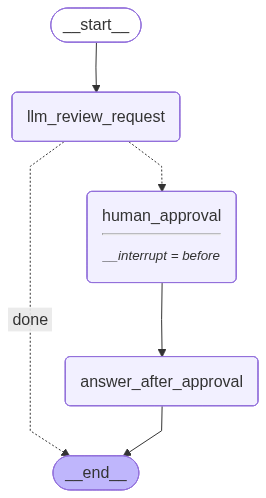

In [34]:
# ------------------------------------------------------------
# 5단계: 그래프 조립 + compile
# ------------------------------------------------------------

approval_builder = StateGraph(ApprovalChatState)
approval_builder.add_node("llm_review_request", llm_review_request)
approval_builder.add_node("human_approval", human_approval)
approval_builder.add_node("answer_after_approval", answer_after_approval)

approval_builder.add_edge(START, "llm_review_request")
approval_builder.add_conditional_edges(
    "llm_review_request",
    route_after_llm,
    {
        "human_approval": "human_approval",
        "done": END,
    },
)
approval_builder.add_edge("human_approval", "answer_after_approval")
approval_builder.add_edge("answer_after_approval", END)

approval_graph = approval_builder.compile(
    checkpointer=MemorySaver(),
    interrupt_before=["human_approval"],  # 승인/거부 입력 직전에 멈춰요
)

# 같은 thread_id를 계속 사용하면 while 루프에서 대화 상태가 이어집니다.
chat_config = {"configurable": {"thread_id": f"approval-chat-{uuid.uuid4()}"}}

print("그래프 컴파일 완료!")
print("thread_id:", chat_config["configurable"]["thread_id"])
approval_graph

### 6단계 — 출력 도우미 함수

`stream(..., stream_mode="values")`는 실행 중간중간 전체 State 값을 보여줍니다. 그런데 매번 전체 메시지를 출력하면 이전 메시지까지 반복해서 보이기 때문에 학생 입장에서는 헷갈릴 수 있습니다.

그래서 아래 함수는 **이번 실행에서 새로 추가된 AI 메시지만** 출력합니다.


In [31]:
# ------------------------------------------------------------
# 6단계: 새 AI 메시지만 출력하는 도우미 함수
# ------------------------------------------------------------

def current_message_count() -> int:
    """이미 출력한 메시지를 중복 출력하지 않기 위해 현재 메시지 개수를 세요."""
    snapshot = approval_graph.get_state(chat_config)
    return len(snapshot.values.get("messages", []))


def print_new_ai_messages(graph_input) -> None:
    """그래프를 실행하면서 새 AI 메시지만 출력해요."""
    seen_count = current_message_count()

    for event in approval_graph.stream(graph_input, chat_config, stream_mode="values"):
        messages = event.get("messages", [])
        for message in messages[seen_count:]:
            if message.type == "ai":
                print(f"\nAI: {message.content}")
        seen_count = len(messages)


### 7단계 — while 루프로 직접 대화하기

이제 실제로 대화해 봅니다.

일반 질문을 입력하면 LLM이 바로 답합니다. 승인이 필요한 요청을 입력하면 다음 일이 일어납니다.

1. LLM이 승인 질문을 출력합니다.
2. 그래프가 `human_approval` 직전에 멈춥니다.
3. while 루프가 사용자에게 `승인` 또는 `거부`를 묻습니다.
4. 입력값이 `update_state(..., as_node="human_approval")`로 State에 기록됩니다.
5. `stream(None, chat_config)`로 그래프가 이어서 실행됩니다.

> 실습 팁: 먼저 `LangGraph의 State가 뭐야?`를 입력해 보고, 다음에는 `배송이 늦었으니 환불 처리해줘.`를 입력해 보세요.


In [32]:
# ------------------------------------------------------------
# 7단계: 스크립트로 대화 실행
# ------------------------------------------------------------
# 노트북 전체 실행 검증에서도 멈추지 않도록 input() 대신 예시 입력을 사용합니다.
# 수업 중 직접 입력을 받고 싶다면 아래 scripted_turns를 원하는 값으로 바꾸면 됩니다.

scripted_turns = [
    ("LangGraph의 State가 뭐야?", None),
    ("배송이 늦었으니 환불 처리해줘.", "승인"),
]

print("스크립트 대화 시작!")

for user_text, scripted_decision in scripted_turns:
    print(f"\n사용자: {user_text}")

    # 새 사용자 입력으로 그래프를 시작합니다.
    print_new_ai_messages({"messages": [HumanMessage(content=user_text)]})

    # 그래프가 어디에서 멈췄는지 확인합니다.
    snapshot = approval_graph.get_state(chat_config)

    # LLM이 승인이 필요하다고 판단하면 human_approval 노드 앞에서 멈춰 있습니다.
    while snapshot.next == ("human_approval",):
        decision = scripted_decision or "거부"
        print(f"\n승인 또는 거부: {decision}")

        # 핵심: 사용자의 판단을 human_approval 노드가 방금 반환한 값처럼 기록합니다.
        approval_graph.update_state(
            chat_config,
            {
                "approval_decision": decision,
                "messages": [HumanMessage(content=f"[사용자 판단] {decision}")],
                "audit_log": [f"사용자가 '{decision}' 입력"],
            },
            as_node="human_approval",
        )

        # None으로 재개하면 human_approval 이후 노드부터 실행됩니다.
        print_new_ai_messages(None)
        snapshot = approval_graph.get_state(chat_config)

print("\n스크립트 대화 종료")


스크립트 대화 시작!

사용자: LangGraph의 State가 뭐야?

AI: LangGraph의 State는 시스템 내에서 객체나 애플리케이션의 현재 상태를 나타냅니다. 이 상태는 데이터 흐름과 상태 관리의 중요한 부분으로, 애플리케이션의 반응성을 높이고 코드의 예측 가능성을 향상시킵니다.

사용자: 배송이 늦었으니 환불 처리해줘.

AI: 이 요청은 사용자 승인이 필요합니다.
이유: 

환불 요청을 승인하시겠습니까? 승인 또는 거부로 답해주세요.

승인 또는 거부: 승인

AI: 승인 확인했습니다.
요청 내용: 배송이 늦었으니 환불 처리해줘.
수업 예제이므로 실제 외부 작업은 실행하지 않고, 여기서는 승인 이후 단계로 진행했다고 기록합니다.

스크립트 대화 종료


### 8단계 — 저장된 State 확인하기

대화를 몇 번 나눈 뒤 아래 셀을 실행해 보세요.

`get_state(chat_config)`는 현재 `thread_id`의 최신 체크포인트를 반환합니다. 여기서 `values`를 보면 메시지, 승인 대기 정보, 감사 로그가 모두 State로 저장되어 있음을 확인할 수 있습니다.


In [33]:
# ------------------------------------------------------------
# 8단계: 현재 체크포인트 State 확인
# ------------------------------------------------------------

snapshot = approval_graph.get_state(chat_config)
values = snapshot.values

print("다음 실행 노드:", snapshot.next or "없음 — 그래프가 현재 턴을 완료했습니다.")
print("메시지 수:", len(values.get("messages", [])))
print("대기 중인 요청:", values.get("pending_request") or "없음")
print("승인 필요 이유:", values.get("approval_reason") or "없음")
print("승인 질문:", values.get("approval_question") or "없음")

print("\n감사 로그")
for index, item in enumerate(values.get("audit_log", []), start=1):
    print(f"{index}. {item}")


다음 실행 노드: 없음 — 그래프가 현재 턴을 완료했습니다.
메시지 수: 6
대기 중인 요청: 없음
승인 필요 이유: 없음
승인 질문: 없음

감사 로그
1. LLM 즉시 답변
2. LLM 승인 요청: 
3. 사용자가 '승인' 입력
4. 사용자 판단 반영: 승인


---

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **Custom State**: TypedDict에 `ask_human: bool` 같은 추가 필드를 넣어서, 노드 분기 조건을 상태로 관리할 수 있어요
- **`update_state(config, values, as_node=)`**: 그래프 외부에서 상태를 수동 업데이트해요. `as_node`로 특정 노드가 실행된 것처럼 처리할 수 있어요
- **ToolMessage 페어링**: `tool_call_id`가 직전 AI 메시지의 `tool_calls[0]["id"]`와 반드시 일치해야 해요
- **메시지 ID 보존**: `add_messages` 리듀서는 같은 ID의 메시지를 replace해요. 도구 파라미터를 수정할 때 `id=existing_message.id`를 유지해야 해요
- **`get_state_history()`**: 전체 체크포인트 히스토리를 역순으로 순회해서, 특정 시점을 선택하고 Replay할 수 있어요
- **승인/거부 HITL 흐름**: `interrupt_before`, `get_state`, `update_state(as_node=...)`, `stream(None, config)`를 조합하면 외부 판단을 State에 주입하고 이어 실행하는 흐름을 체험할 수 있어요


## 다음 노트북 예고

다음 `Part 03 / 01-Workflows-vs-Agents.ipynb`에서는 **LangGraph로 구현할 수 있는 6가지 워크플로우 패턴**을 배워요. 반복, 병렬 분기, 라우팅 등 실무에서 자주 쓰는 패턴들을 코드로 직접 구현해볼게요.
